In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


DYNAMIC SELECTION SUCCESSFUL
Empirical Validation Winner : Degree 5
Validation Minimum MSE     : 0.05118
------------------------------------------------------------
FINAL UNBIASED TEST EVALUATION
Reported Test Set MSE      : 0.07014


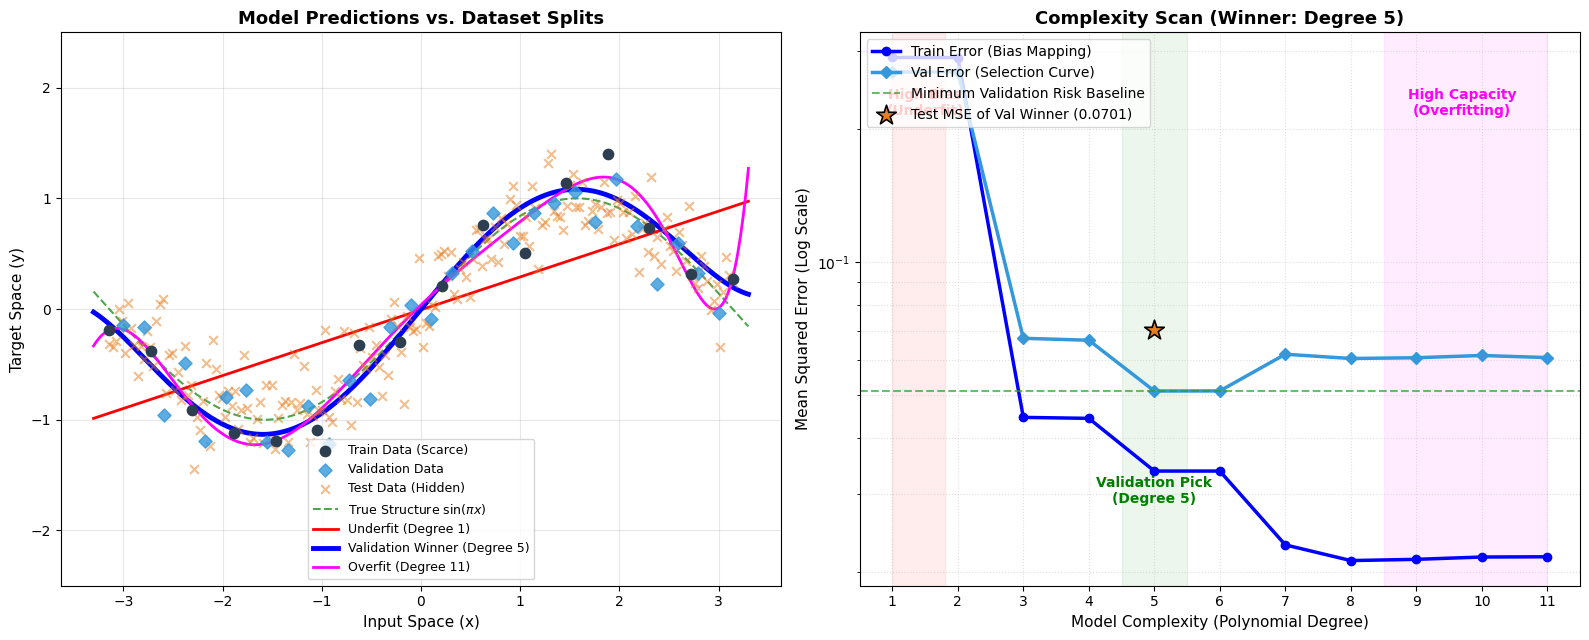

In [2]:

# ============================================================
# 1. REPRODUCIBILITY & DATA GENERATION (3-Way Split)
# ============================================================
torch.manual_seed(15)  # Seed selected for highly erratic edge oscillations
np.random.seed(15)

def true_function(x):
    return torch.sin(x)

# Training Set (Scarce, noisy coordinates to induce variance)
N_train = 16
x_train = torch.linspace(-3.14, 3.14, N_train).unsqueeze(1)
y_train = true_function(x_train) + torch.randn_like(x_train) * 0.22

# Validation Set (Used exclusively to select the best hyperparameter/weight decay)
N_val = 30
x_val = torch.linspace(-3.0, 3.0, N_val).unsqueeze(1)
y_val = true_function(x_val) + torch.randn_like(x_val) * 0.22

# Test Set (Completely hidden during tuning, used only for the final unbiased report)
N_test = 200
x_test = torch.linspace(-3.14, 3.14, N_test).unsqueeze(1)
y_test = true_function(x_test) + torch.randn_like(x_test) * 0.22

x_range = torch.linspace(-3.3, 3.3, 500).unsqueeze(1)

# ============================================================
# 2. FEATURE EXTRACTION HELPER WITH TRAINING-ANCHORED SCALING
# ============================================================
def generate_poly_features(x_target, degree, x_reference):
    raw_target = torch.cat([x_target ** i for i in range(1, degree + 1)], dim=1)
    raw_ref    = torch.cat([x_reference ** i for i in range(1, degree + 1)], dim=1)
    
    col_max, _ = torch.max(torch.abs(raw_ref), dim=0, keepdim=True)
    col_max = torch.clamp(col_max, min=1e-8)
    
    return raw_target / col_max

# ============================================================
# 3. TRAINING ENGINE
# ============================================================
def train_polynomial_model(degree, epochs=8000, lr=0.02):
    X_train_poly = generate_poly_features(x_train, degree, x_train)
    X_val_poly   = generate_poly_features(x_val, degree, x_train)
    X_test_poly  = generate_poly_features(x_test, degree, x_train)
    X_range_poly = generate_poly_features(x_range, degree, x_train)
    
    model = nn.Linear(degree, 1)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_poly), y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        train_mse = criterion(model(X_train_poly), y_train).item()
        val_mse   = criterion(model(X_val_poly), y_val).item()
        test_mse  = criterion(model(X_test_poly), y_test).item()
        range_preds = model(X_range_poly)
        
    return train_mse, val_mse, test_mse, range_preds

# ============================================================
# 4. SWEEPING DEGREES FOR VISUALIZATION & DYNAMIC SELECTION
# ============================================================
degrees = list(range(1, 12))
train_errors = []
val_errors = []
test_errors = []
predictions_dict = {}

for d in degrees:
    tr_err, va_err, te_err, preds = train_polynomial_model(degree=d)
    train_errors.append(tr_err)
    val_errors.append(va_err)
    test_errors.append(te_err)
    predictions_dict[d] = preds

# --- DYNAMIC VALIDATION WINNER SELECTION ---
best_idx = np.argmin(val_errors) 
OPTIMAL_DEGREE = degrees[best_idx]  # Dynamically extracts the absolute best on validation
target_train_mse = train_errors[best_idx]
target_val_mse = val_errors[best_idx]
target_test_mse = test_errors[best_idx]

print("="*60)
print(f"DYNAMIC SELECTION SUCCESSFUL")
print(f"Empirical Validation Winner : Degree {OPTIMAL_DEGREE}")
print(f"Validation Minimum MSE     : {target_val_mse:.5f}")
print("-"*60)
print(f"FINAL UNBIASED TEST EVALUATION")
print(f"Reported Test Set MSE      : {target_test_mse:.5f}")
print("="*60)

# ============================================================
# 5. SIDE-BY-SIDE VISUALIZATION
# ============================================================
plt.figure(figsize=(16, 6.5))

# --- Plot 1: Visual Predictions (Highlighting the True Validation Winner) ---
plt.subplot(1, 2, 1)
plt.scatter(x_train.numpy(), y_train.numpy(), color='#2c3e50', s=55, label='Train Data (Scarce)', zorder=5)
plt.scatter(x_val.numpy(), y_val.numpy(), color='#3498db', marker='D', alpha=0.8, s=45, label='Validation Data', zorder=4)
plt.scatter(x_test.numpy(), y_test.numpy(), color='#e67e22', marker='x', alpha=0.5, s=40, label='Test Data (Hidden)', zorder=3)

plt.plot(x_range.numpy(), true_function(x_range).numpy(), color='green', linestyle='--', alpha=0.7, label='True Structure $\sin(\pi x)$')

# Display an underfit, the dynamically chosen validation winner, and an overfit model
display_degrees = {
    1: ('red', 'Underfit (Degree 1)'), 
    OPTIMAL_DEGREE: ('blue', f'Validation Winner (Degree {OPTIMAL_DEGREE})'), 
    11: ('magenta', 'Overfit (Degree 11)')
}

for d, (color, label) in display_degrees.items():
    linewidth = 3.5 if d == OPTIMAL_DEGREE else 2.0
    plt.plot(x_range.numpy(), predictions_dict[d].numpy(), color=color, linewidth=linewidth, label=label)

plt.ylim(-2.5, 2.5)
plt.title("Model Predictions vs. Dataset Splits", fontsize=13, fontweight='bold')
plt.xlabel("Input Space (x)", fontsize=11)
plt.ylabel("Target Space (y)", fontsize=11)
plt.legend(loc='lower center', fontsize=9)
plt.grid(True, alpha=0.3)

# --- Plot 2: Complexity Sweep with Dynamically Located Test Point ---
ax2 = plt.subplot(1, 2, 2)
plt.plot(degrees, train_errors, marker='o', markersize=6, color='blue', linewidth=2.5, label='Train Error (Bias Mapping)')
plt.plot(degrees, val_errors, marker='D', markersize=6, color='#3498db', linewidth=2.5, label='Val Error (Selection Curve)')
plt.axhline(y=target_val_mse, color='tab:green', linestyle='--', linewidth=1.5, alpha=0.7, label='Minimum Validation Risk Baseline')

# Track the star point directly to whatever index mathematically won the validation sweep
plt.scatter(OPTIMAL_DEGREE, target_test_mse, color='#e67e22', marker='*', s=220, zorder=6, 
            edgecolors='black', linewidths=1.2, label=f'Test MSE of Val Winner ({target_test_mse:.4f})')

plt.yscale('log')
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=11)
plt.ylabel("Mean Squared Error (Log Scale)", fontsize=11)
plt.title(f"Complexity Scan (Winner: Degree {OPTIMAL_DEGREE})", fontsize=13, fontweight='bold')
plt.xticks(degrees)
plt.grid(True, which="both", alpha=0.4, linestyle=':')

# Structural boundaries
plt.axvspan(1, 1.8, color='red', alpha=0.07)
plt.text(1.5, 0.85, "High Bias\n(Underfit)", color='red', fontsize=10, weight='bold', ha='center', transform=ax2.get_xaxis_transform())

plt.axvspan(OPTIMAL_DEGREE - 0.5, OPTIMAL_DEGREE + 0.5, color='green', alpha=0.07)
plt.text(OPTIMAL_DEGREE, 0.15, f"Validation Pick\n(Degree {OPTIMAL_DEGREE})", color='green', fontsize=10, weight='bold', ha='center', transform=ax2.get_xaxis_transform())

plt.axvspan(8.5, 11, color='magenta', alpha=0.07)
plt.text(9.7, 0.85, "High Capacity\n(Overfitting)", color='magenta', fontsize=10, weight='bold', ha='center', transform=ax2.get_xaxis_transform())

plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

Training Underfit Model (1 Neuron)...
Training Overfit Model (1024 Neurons, No Regularization)...

Sweeping regularization strengths over Validation Space...
 > Weight Decay: 0.001  | Val MSE: 0.0691
 > Weight Decay: 0.005  | Val MSE: 0.0534
 > Weight Decay: 0.01   | Val MSE: 0.0509
 > Weight Decay: 0.015  | Val MSE: 0.0543
 > Weight Decay: 0.03   | Val MSE: 0.0483
 > Weight Decay: 0.05   | Val MSE: 0.0540

--> Validation Winner selected: Weight Decay = 0.03 (Val MSE: 0.0483)
--> Final Unbiased Test Performance for Selection: 0.0533



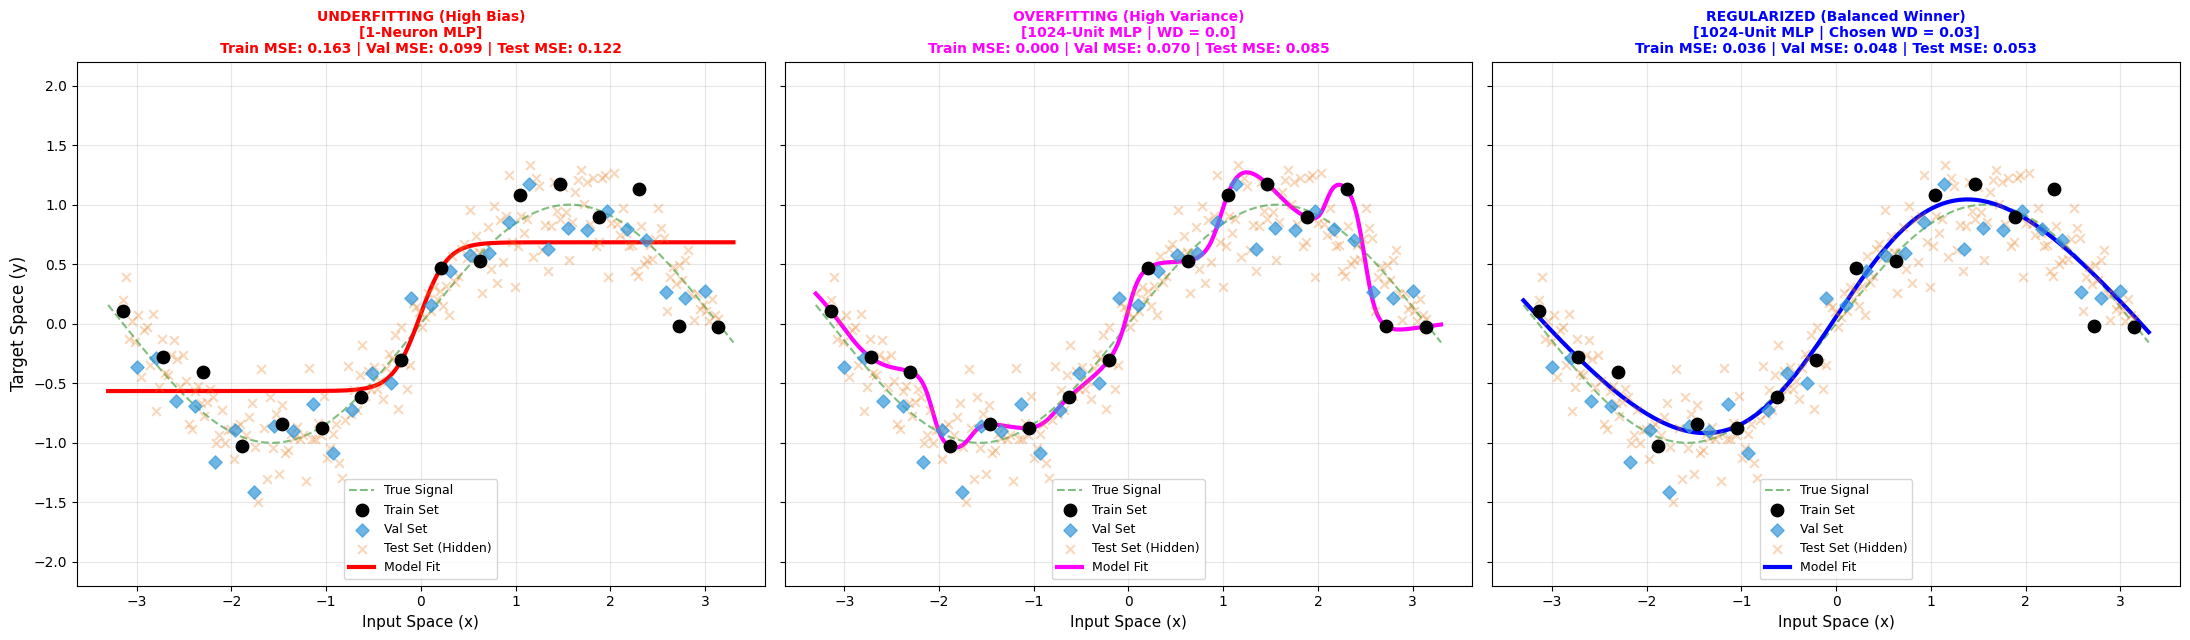

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. REPRODUCIBILITY & DATA GENERATION (3-Way Split)
# ============================================================
torch.manual_seed(20) 
np.random.seed(20)

def true_function(x):
    # Pure sine wave mapping across domain bounds (-pi to pi)
    return torch.sin(x)

# Training Set (Scarce, noisy coordinates to induce variance)
N_train = 16
x_train = torch.linspace(-3.14, 3.14, N_train).unsqueeze(1)
y_train = true_function(x_train) + torch.randn_like(x_train) * 0.22

# Validation Set (Used exclusively to select the best hyperparameter/weight decay)
N_val = 30
x_val = torch.linspace(-3.0, 3.0, N_val).unsqueeze(1)
y_val = true_function(x_val) + torch.randn_like(x_val) * 0.22

# Test Set (Completely hidden during tuning, used only for the final unbiased report)
N_test = 200
x_test = torch.linspace(-3.14, 3.14, N_test).unsqueeze(1)
y_test = true_function(x_test) + torch.randn_like(x_test) * 0.22

x_range = torch.linspace(-3.3, 3.3, 500).unsqueeze(1)

# ============================================================
# 2. ARCHITECTURE CODES (Structural vs. Regularized Control)
# ============================================================
class DemonstrationMLP(nn.Module):
    def __init__(self, mode):
        super().__init__()
        
        if mode == "underfit":
            # Structural Bottleneck: 1 Neuron cannot replicate an S-curve/Sine wave
            self.network = nn.Sequential(
                nn.Linear(1, 1),
                nn.Tanh(),
                nn.Linear(1, 1)
            )
        elif mode in ["overfit", "regularized"]:
            # Massive structural capacity 
            self.network = nn.Sequential(
                nn.Linear(1, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1)  
            )

    def forward(self, x):
        return self.network(x)

# ============================================================
# 3. TRAINING ENGINE
# ============================================================
def train_model(mode, epochs, lr, weight_decay=0.0):
    model = DemonstrationMLP(mode)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(x_train), y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        train_mse = criterion(model(x_train), y_train).item()
        val_mse   = criterion(model(x_val), y_val).item()
        test_mse  = criterion(model(x_test), y_test).item()
        preds     = model(x_range)
        
    return train_mse, val_mse, test_mse, preds

# ============================================================
# 4. RUNNING EXPERIMENTS WITH HYPERPARAMETER TUNING
# ============================================================
print("Training Underfit Model (1 Neuron)...")
underfit_train, underfit_val, underfit_test, underfit_preds = train_model(
    "underfit", epochs=3000, lr=0.01
)

print("Training Overfit Model (1024 Neurons, No Regularization)...")
overfit_train, overfit_val, overfit_test, overfit_preds = train_model(
    "overfit", epochs=8000, lr=0.0003, weight_decay=0.0
)

# --- Dynamic Hyperparameter Optimization via Validation Set ---
print("\nSweeping regularization strengths over Validation Space...")
weight_decay_candidates = [0.001, 0.005, 0.01, 0.015, 0.03, 0.05]
best_val_mse = float('inf')

best_reg_results = None
chosen_wd = 0.0

for wd in weight_decay_candidates:
    tr, va, te, pr = train_model("regularized", epochs=8000, lr=0.0003, weight_decay=wd)
    print(f" > Weight Decay: {wd:<6} | Val MSE: {va:.4f}")
    
    # Validation strictly controls who wins the selection phase!
    if va < best_val_mse:
        best_val_mse = va
        chosen_wd = wd
        best_reg_results = (tr, va, te, pr)

reg_train, reg_val, reg_test, reg_preds = best_reg_results
print(f"\n--> Validation Winner selected: Weight Decay = {chosen_wd} (Val MSE: {reg_val:.4f})")
print(f"--> Final Unbiased Test Performance for Selection: {reg_test:.4f}\n")

# ============================================================
# 5. HIGH-VISIBILITY VISUALIZATION (3-Way Split Version)
# ============================================================
fig, axs = plt.subplots(1, 3, figsize=(22, 6.5), sharey=True)

for ax in axs:
    ax.plot(x_range.numpy(), true_function(x_range).numpy(), color='green', linestyle='--', alpha=0.5, label='True Signal')
    ax.scatter(x_train.numpy(), y_train.numpy(), color='black', s=80, label='Train Set', zorder=5)
    ax.scatter(x_val.numpy(), y_val.numpy(), color='#3498db', marker='D', s=45, alpha=0.7, label='Val Set', zorder=4)
    ax.scatter(x_test.numpy(), y_test.numpy(), color='#e67e22', marker='x', s=40, alpha=0.3, label='Test Set (Hidden)', zorder=3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Input Space (x)", fontsize=11)

axs[0].set_ylabel("Target Space (y)", fontsize=12)

# --- PANEL 1: UNDERFITTING (High Bias) ---
axs[0].plot(x_range.numpy(), underfit_preds.numpy(), color='red', linewidth=3, label='Model Fit')
title_0 = (f"UNDERFITTING (High Bias)\n[1-Neuron MLP]\n"
           f"Train MSE: {underfit_train:.3f} | Val MSE: {underfit_val:.3f} | Test MSE: {underfit_test:.3f}")
axs[0].set_title(title_0, color='red', fontsize=10, fontweight='bold')
axs[0].legend(loc='lower center', fontsize=9)

# --- PANEL 2: OVERFITTING (High Variance) ---
axs[1].plot(x_range.numpy(), overfit_preds.numpy(), color='magenta', linewidth=3, label='Model Fit')
title_1 = (f"OVERFITTING (High Variance)\n[1024-Unit MLP | WD = 0.0]\n"
           f"Train MSE: {overfit_train:.3f} | Val MSE: {overfit_val:.3f} | Test MSE: {overfit_test:.3f}")
axs[1].set_title(title_1, color='magenta', fontsize=10, fontweight='bold')
axs[1].legend(loc='lower center', fontsize=9)

# --- PANEL 3: REGULARIZED OPTIMAL (Validation Driven Selection) ---
axs[2].plot(x_range.numpy(), reg_preds.numpy(), color='blue', linewidth=3, label='Model Fit')
title_2 = (f"REGULARIZED (Balanced Winner)\n[1024-Unit MLP | Chosen WD = {chosen_wd}]\n"
           f"Train MSE: {reg_train:.3f} | Val MSE: {reg_val:.3f} | Test MSE: {reg_test:.3f}")
axs[2].set_title(title_2, color='blue', fontsize=10, fontweight='bold')
axs[2].legend(loc='lower center', fontsize=9)

plt.ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()

BEST MODEL SELECTION (Stabilized Variance)
Optimal Polynomial Degree : Degree 3
Validation MSE             : 1.1251
Performance on TEST Set   : 1.0094 (MSE)


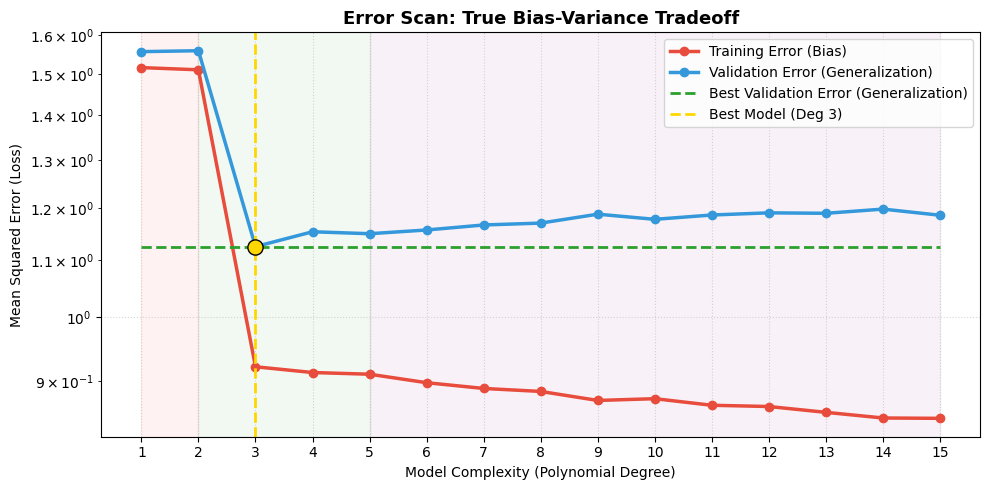

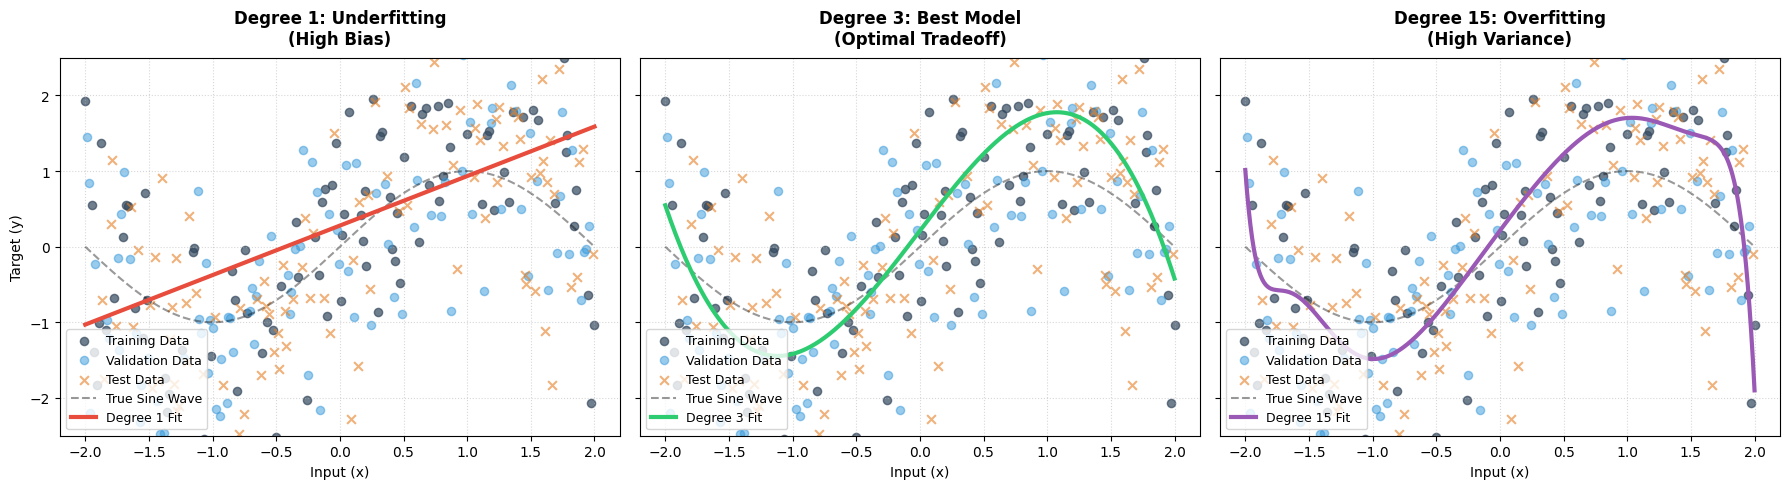

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP DATA (Stabilized Sample Size)
# ==========================================
torch.manual_seed(42)
np.random.seed(42)

# Generate 300 points total (100 Train / 100 Val / 100 Test)
X_all = torch.linspace(-2, 2, 300).unsqueeze(1)
y_all = 1.5 * torch.sin(X_all * np.pi / 2) + torch.randn(X_all.shape) 

indices = torch.randperm(300)
train_idx, val_idx, test_idx = indices[:100], indices[100:200], indices[200:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

# Dense line for generating smooth visual curves
X_line = torch.linspace(-2, 2, 300).unsqueeze(1)
y_line = torch.sin(X_line * np.pi / 2)

# ==========================================
# 2. FEATURE SCALING HELPER
# ==========================================
def get_scaled_poly_features(X_target, degree, X_reference):
    """
    Generates polynomial features for X_target, scaled strictly using the 
    maximum values calculated from X_reference (Train Set) to avoid data leakage.
    """
    raw_target = torch.cat([X_target**i for i in range(1, degree + 1)], dim=1)
    raw_ref = torch.cat([X_reference**i for i in range(1, degree + 1)], dim=1)
    
    col_max, _ = torch.max(torch.abs(raw_ref), dim=0, keepdim=True)
    col_max = torch.clamp(col_max, min=1e-8)
    
    return raw_target / col_max

# ==========================================
# 3. COMPLEXITY SCAN LOOP
# ==========================================
max_degree = 15
degrees = list(range(1, max_degree + 1))
train_errors = []
val_errors = []

trained_models = {}
criterion = nn.MSELoss()

for deg in degrees:
    X_poly_train = get_scaled_poly_features(X_train, deg, X_train)
    X_poly_val   = get_scaled_poly_features(X_val, deg, X_train)
    
    model = nn.Linear(deg, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    
    # Train to stable convergence
    for epoch in range(1500):
        optimizer.zero_grad()
        loss = criterion(model(X_poly_train), y_train)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_poly_train), y_train).item()
        val_loss = criterion(model(X_poly_val), y_val).item()
        
    train_errors.append(train_loss)
    val_errors.append(val_loss)
    
    trained_models[deg] = model

# ==========================================
# 4. EVALUATE WINNER ON HIDDEN TEST SET
# ==========================================
best_degree = degrees[np.argmin(val_errors)]
best_model = trained_models[best_degree]

X_poly_test = get_scaled_poly_features(X_test, best_degree, X_train)
best_model.eval()
with torch.no_grad():
    test_loss = criterion(best_model(X_poly_test), y_test).item()

print("=" * 60)
print(f"BEST MODEL SELECTION (Stabilized Variance)")
print("=" * 60)
print(f"Optimal Polynomial Degree : Degree {best_degree}")
print(f"Validation MSE             : {min(val_errors):.4f}")
print(f"Performance on TEST Set   : {test_loss:.4f} (MSE)")
print("=" * 60)

# ==========================================
# 5. PLOT 1: THE ERROR SCAN CURVES
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_errors, 'o-', color='#e74c3c', linewidth=2.5, label='Training Error (Bias)')
plt.plot(degrees, val_errors, 'o-', color='#3498db', linewidth=2.5, label='Validation Error (Generalization)')

plt.title('Error Scan: True Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error (Loss)')
plt.xticks(degrees)
plt.yscale('log') 
plt.grid(True, linestyle=':', alpha=0.5)

plt.axvspan(1, 2, color='red', alpha=0.05)
plt.axvspan(2, 5, color='green', alpha=0.05)
plt.axvspan(5, max_degree, color='purple', alpha=0.05)
plt.plot(degrees, np.min(val_errors)*np.ones_like(degrees), color='tab:green', linestyle='--', linewidth=2, label='Best Validation Error (Generalization)')

plt.axvline(x=best_degree, color='gold', linestyle='--', linewidth=2, label=f'Best Model (Deg {best_degree})')
plt.scatter(best_degree, min(val_errors), color='gold', s=120, zorder=5, edgecolor='black')
plt.legend()
plt.tight_layout()

# ==========================================
# 6. PLOT 2: VISUAL FITS COMPARISON
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_degrees = [1, best_degree, 15]
titles = [
    "Degree 1: Underfitting\n(High Bias)",
    f"Degree {best_degree}: Best Model\n(Optimal Tradeoff)",
    "Degree 15: Overfitting\n(High Variance)"
]
colors = ['#e74c3c', '#2ecc71', '#9b59b6']

for i, deg in enumerate(plot_degrees):
    ax = axes[i]
    
    # Generate predictions across the continuous line space
    X_poly_line = get_scaled_poly_features(X_line, deg, X_train)
    m = trained_models[deg]
    m.eval()
    with torch.no_grad():
        line_preds = m(X_poly_line).numpy()
        
    # Plot data points with explicit group identities
    ax.scatter(X_train.numpy(), y_train.numpy(), color='#34495e', alpha=0.7, s=35, label='Training Data')
    ax.scatter(X_val.numpy(), y_val.numpy(), color='#3498db', alpha=0.5, s=35, label='Validation Data')
    ax.scatter(X_test.numpy(), y_test.numpy(), color='#e67e22', marker='x', alpha=0.6, s=40, label='Test Data')
    
    # Plot true vs predicted profiles
    ax.plot(X_line.numpy(), y_line.numpy(), 'k--', alpha=0.4, label='True Sine Wave')
    ax.plot(X_line.numpy(), line_preds, color=colors[i], linewidth=3, label=f'Degree {deg} Fit')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Input (x)')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        ax.set_ylabel('Target (y)')
    ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

FINAL PERFORMANCE SUMMARY
1. Single Neuron        | Train: 0.2986 | Val: 0.3328 | Test: 0.3122
2. 3-Layer MLP (No Reg) | Train: 0.0065 | Val: 0.2728 | Test: 0.2400
3. 3-Layer MLP + Reg    | Train: 0.0647 | Val: 0.1209 | Test: 0.0789
---------------------------------------------------------------------------
WINNER (Selected by Val Performance): 3-Layer MLP With Regularization (Balanced)
   -> Final Unseen Test Set MSE: 0.0789


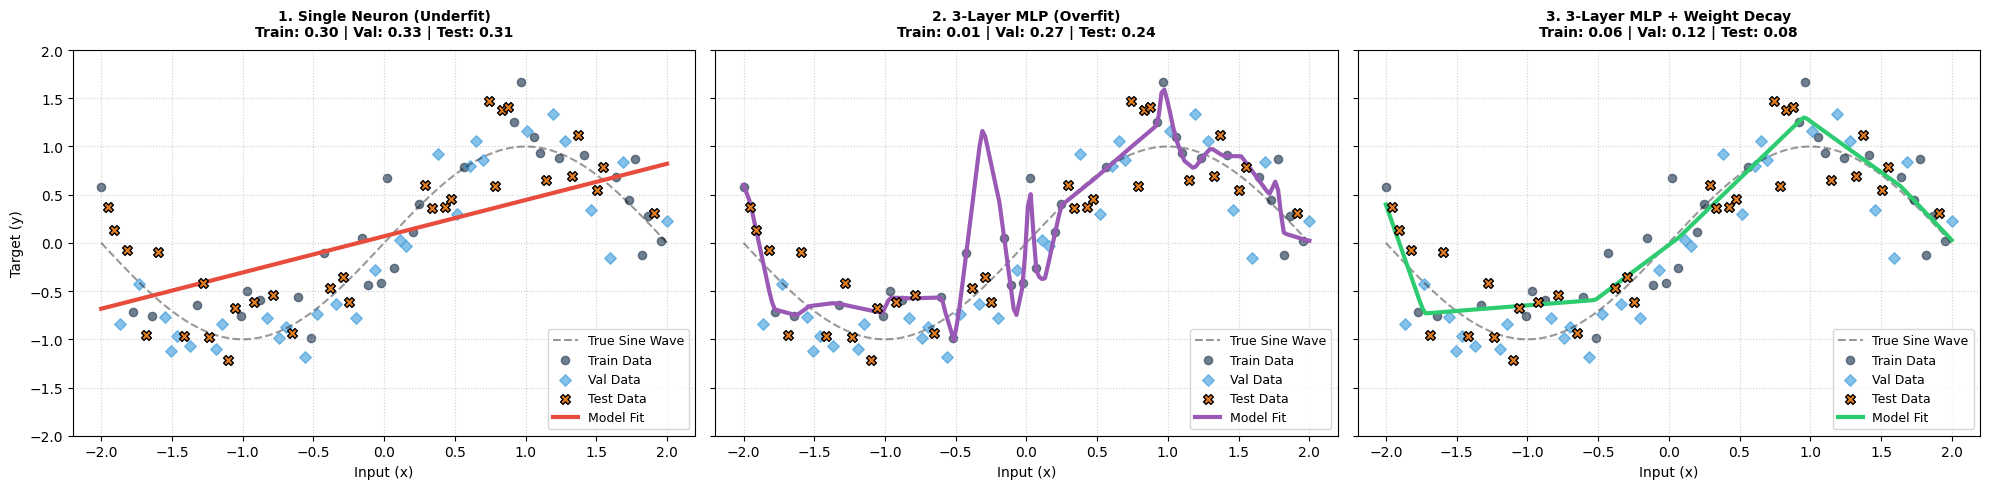

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data (Noisy Sine Wave with 3-Way Split)
torch.manual_seed(42)
np.random.seed(42)

# Generate an expanded dataset to cleanly accommodate 3 distinct splits
X_all = torch.linspace(-2, 2, 90).unsqueeze(1)
y_all = torch.sin(X_all * np.pi / 2) + torch.randn(X_all.shape) * 0.3

# Shuffle and split equally (1/3 Train, 1/3 Val, 1/3 Test)
indices = torch.randperm(90)
train_idx, val_idx, test_idx = indices[:30], indices[30:60], indices[60:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val     = X_all[val_idx], y_all[val_idx]
X_test, y_test   = X_all[test_idx], y_all[test_idx]

# Dense line for plotting smooth model predictions
X_line = torch.linspace(-2, 2, 200).unsqueeze(1)
y_line = torch.sin(X_line * np.pi / 2)

# 2. Define Architectures

# Model A: Single Neuron (Linear Regression)
class SingleNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

# Model B & C: Deep MLP (3 Layers)
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

# Instantiate models
model_neuron = SingleNeuron()
model_mlp = DeepMLP()
model_mlp_reg = DeepMLP()

# 3. Define Optimizers (Applying Weight Decay only to the regularized model)
criterion = nn.MSELoss()
epochs = 5000
lr = 0.01

opt_neuron = torch.optim.Adam(model_neuron.parameters(), lr=lr)
opt_mlp    = torch.optim.Adam(model_mlp.parameters(), lr=lr)
opt_reg    = torch.optim.Adam(model_mlp_reg.parameters(), lr=lr, weight_decay=3e-3)

# 4. Training Loop (Using Training Set Only)
for epoch in range(epochs):
    # Train Single Neuron
    model_neuron.train()
    loss_n = criterion(model_neuron(X_train), y_train)
    opt_neuron.zero_grad()
    loss_n.backward()
    opt_neuron.step()
    
    # Train Unregularized MLP
    model_mlp.train()
    loss_m = criterion(model_mlp(X_train), y_train)
    opt_mlp.zero_grad()
    loss_m.backward()
    opt_mlp.step()
    
    # Train Regularized MLP
    model_mlp_reg.train()
    loss_r = criterion(model_mlp_reg(X_train), y_train)
    opt_reg.zero_grad()
    loss_r.backward()
    opt_reg.step()

# 5. Evaluate Performance on Train, Val, and Hidden Test Sets
model_neuron.eval()
model_mlp.eval()
model_mlp_reg.eval()

with torch.no_grad():
    # Calculate Final Train Losses
    train_loss_neuron = criterion(model_neuron(X_train), y_train).item()
    train_loss_mlp    = criterion(model_mlp(X_train), y_train).item()
    train_loss_reg    = criterion(model_mlp_reg(X_train), y_train).item()

    # Calculate Final Validation Losses (Used for picking/tuning models)
    val_loss_neuron   = criterion(model_neuron(X_val), y_val).item()
    val_loss_mlp      = criterion(model_mlp(X_val), y_val).item()
    val_loss_reg      = criterion(model_mlp_reg(X_val), y_val).item()

    # Calculate Final Test Losses (The final blind evaluation benchmark)
    test_loss_neuron  = criterion(model_neuron(X_test), y_test).item()
    test_loss_mlp     = criterion(model_mlp(X_test), y_test).item()
    test_loss_reg     = criterion(model_mlp_reg(X_test), y_test).item()
    
    # Generate dense lines for visual evaluation plots
    pred_neuron = model_neuron(X_line)
    pred_mlp    = model_mlp(X_line)
    pred_reg    = model_mlp_reg(X_line)

# 6. Print Performance Summary & Identify Best Model (Using Validation set to pick)
print("=" * 75)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 75)
print(f"1. Single Neuron        | Train: {train_loss_neuron:.4f} | Val: {val_loss_neuron:.4f} | Test: {test_loss_neuron:.4f}")
print(f"2. 3-Layer MLP (No Reg) | Train: {train_loss_mlp:.4f} | Val: {val_loss_mlp:.4f} | Test: {test_loss_mlp:.4f}")
print(f"3. 3-Layer MLP + Reg    | Train: {train_loss_reg:.4f} | Val: {val_loss_reg:.4f} | Test: {test_loss_reg:.4f}")
print("-" * 75)

# Selection criteria based strictly on validation results
val_results = {
    "Single Neuron (Underfitting)": (val_loss_neuron, test_loss_neuron),
    "3-Layer MLP Without Regularization (Overfitting)": (val_loss_mlp, test_loss_mlp),
    "3-Layer MLP With Regularization (Balanced)": (val_loss_reg, test_loss_reg)
}
best_model_name = min(val_results, key=lambda k: val_results[k][0])
best_model_test_score = val_results[best_model_name][1]

print(f"WINNER (Selected by Val Performance): {best_model_name}")
print(f"   -> Final Unseen Test Set MSE: {best_model_test_score:.4f}")
print("=" * 75)

# 7. Plotting the Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
titles = [
    f"1. Single Neuron (Underfit)\nTrain: {train_loss_neuron:.2f} | Val: {val_loss_neuron:.2f} | Test: {test_loss_neuron:.2f}", 
    f"2. 3-Layer MLP (Overfit)\nTrain: {train_loss_mlp:.2f} | Val: {val_loss_mlp:.2f} | Test: {test_loss_mlp:.2f}", 
    f"3. 3-Layer MLP + Weight Decay\nTrain: {train_loss_reg:.2f} | Val: {val_loss_reg:.2f} | Test: {test_loss_reg:.2f}"
]
predictions = [pred_neuron, pred_mlp, pred_reg]
colors = ['#e74c3c', '#9b59b6', '#2ecc71']

for i, ax in enumerate(axes):
    # Plot baseline truth
    ax.plot(X_line.numpy(), y_line.numpy(), 'k--', alpha=0.4, label='True Sine Wave')
    
    # Plot three distinct data split profiles
    ax.scatter(X_train.numpy(), y_train.numpy(), color='#34495e', alpha=0.7, s=35, label='Train Data')
    ax.scatter(X_val.numpy(), y_val.numpy(), color='#3498db', marker='D', alpha=0.6, s=35, label='Val Data')
    ax.scatter(X_test.numpy(), y_test.numpy(), color='#e67e22', marker='X', edgecolor='k', s=50, zorder=3, label='Test Data')
    
    # Plot model fit representation
    ax.plot(X_line.numpy(), predictions[i].numpy(), color=colors[i], linewidth=3, label='Model Fit')
    
    ax.set_title(titles[i], fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Input (x)')
    ax.set_ylim(-2, 2)
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 0:
        ax.set_ylabel('Target (y)')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

In statistical learning theory and the framework of **Empirical Risk Minimization (ERM)**, the behavior of a learning algorithm is governed by the relationship between the sample size $N$, the capacity of the hypothesis space $\mathcal{H}$, and the true data-generating distribution $P(X, Y)$.

When these parameters are altered—such as moving from a scarce data regime ($N=15$) to a dense data regime ($N=150$)—the geometric and statistical properties of the model undergo profound transformations. Below is an academic decomposition of **Spurious Generalization**, the **Validation Anomaly**, and the **Bias-Variance Shift**.

---

## 1. Spurious Generalization

**Spurious Generalization** refers to a phenomenon where a high-capacity model yields a low empirical risk on a held-out validation set, falsely indicating robust out-of-sample generalization when it has actually memorized artifactual or stochastic properties of the data split.

In learning theory, the generalization gap is bounded by the **Rademacher Complexity** $\mathcal{R}_S(\mathcal{H})$ of the hypothesis space. For any model $f \in \mathcal{H}$, with probability at least $1 - \delta$, the true risk $R(f)$ is bounded by the empirical risk $\hat{R}_S(f)$:

$$R(f) \le \hat{R}_S(f) + 2\mathcal{R}_S(\mathcal{H}) + O\left(\sqrt{\frac{\ln(1/\delta)}{2N}}\right)$$

### Theoretical Mechanics

* **Loose Bounds in Finite Samples:** When the sample size $N$ is small, the right-hand complexity penalty explodes. The hypothesis class is flexible enough to express a vast arrangement of functions.
* **Coincidental Alignment:** Spurious generalization occurs when an overparameterized model undergoes high-frequency oscillations that fortuitously align with the discrete coordinates of the validation sample.
* **The Illusion of Learning:** The model minimizes empirical validation risk not by capturing the true underlying target function $f(x)$, but by finding a mathematically convoluted path that satisfies the training points while incidentally passing through the sparse validation points.

---

## 2. The Validation Anomaly

The **Validation Anomaly** describes a structural breakdown in the empirical validation curve during a complexity sweep. Instead of forming the classical U-shaped curve dictated by the bias-variance tradeoff, the validation error curve displays a deceptive local or global minimum at an extreme complexity level (e.g., a Degree 11 or 15 polynomial winning the selection process).

```
        The Classical U-Curve                      The Validation Anomaly
     
     Error                                      Error
       ^                                          ^
       |  \          / Overfitting                |  \          
       |   \        /                             |   \         /---\ Spurious
       |    \______/                              |    \_______/     \ Drop!
       |   Optimal Complexity                     |   Optimal?        
       +-------------------->                     +-------------------->
             Complexity                                 Complexity

```

### Theoretical Mechanics

* **Discrete Space Undersampling:** A validation curve relies on the assumption that the validation set $\mathcal{D}_{val}$ is a representative proxy for the true risk $R(f)$. If $|\mathcal{D}_{val}|$ is small, large interstitial spaces exist between data coordinates.
* **Nodal Intersections:** An overfitted, high-degree polynomial oscillates violently within these interstitial spaces. The true risk of this model is technically massive. However, if the validation points happen to sit near the roots or turning points of these wild oscillations, the empirical validation risk evaluates to a near-zero value:

$$\hat{R}_{val}(f) = \frac{1}{N_{val}} \sum_{i=1}^{N_{val}} L(y_i, f(x_i)) \ll R(f)$$

* **The Selection Trap:** This numerical anomaly invalidates the validation set as an unbiased estimator of generalization, forcing the practitioner to mistakenly select a brittle, high-variance model.

---

## 3. The Bias-Variance Shift

**The Bias-Variance Shift** describes the fundamental transformation of a model's error profile when the training set cardinality $N$ scales asymptotically toward infinity. It represents the transition of a hypothesis space from a **variance-dominated** regime to a **bias-bounded** regime.

Recall the standard expected prediction error decomposition at a query point $x$:

$$\mathbb{E}_{\mathcal{D}}[(y - \hat{f}(x; \mathcal{D}))^2] = \text{Bias}(\hat{f}(x))^2 + \text{Var}(\hat{f}(x)) + \sigma^2$$

### The Mechanics of the Shift

| Metric | Low-Data Regime ($N \to 0$) | High-Data Regime ($N \to \infty$) |
| --- | --- | --- |
| **Variance Behavior** | **Explosive:** $\text{Var}(\hat{f}(x))$ dominates. Subtle shifts in $\mathcal{D}$ cause massive structural changes in $\hat{f}$. | **Asymptotic Decay:** $\text{Var}(\hat{f}(x)) \to 0$. The data density overdetermines the optimization landscape. |
| **Geometric Freedom** | **Unconstrained:** High-degree functions fluctuate wildly in the empty spaces between points. | **Constrained:** Interstitial gaps collapse. High-frequency oscillations are suppressed by neighboring data points. |
| **Error Curve Shape** | **U-Shaped:** Clear, penalizing upward curve on the right due to exploding variance. | **L-Shaped / Flat:** Drops sharply when bias is satisfied, then plateaus because variance is neutralized. |

### Mathematical Convergence

By the **Law of Large Numbers** and uniform convergence theorems (such as the Vapnik-Chervonenkis bound), as $N \to \infty$, the empirical risk surface converges uniformly to the true risk surface:

$$\sup_{f \in \mathcal{H}} | \hat{R}_N(f) - R(f) | \to 0$$

When you flood the model with data (e.g., $N=150$), the data acts as an **implicit geometric regularizer**. A Degree 11 polynomial possesses the *capacity* to oscillate, but it cannot do so without violating the empirical risk minimization objective across the hundreds of densely packed data coordinates.

Consequently, the variance component of the high-capacity model collapses, causing the right side of the error sweep to flatten into a stable, non-destructive plateau.